# XGBoost Model Training


## Load Cleaned Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

clean_train = pd.read_csv("data/clean_train.csv")
clean_val = pd.read_csv("data/clean_val.csv")

# The cleaned CSVs keep Place_ID and Date for feature engineering, but models should not train on them.
metadata_cols = ["Place_ID", "Date", "Place_ID X Date"]
drop_cols = ["target"] + [col for col in metadata_cols if col in clean_train.columns]

X_tr = clean_train.drop(columns=drop_cols)
y_tr = clean_train["target"]
X_val = clean_val.drop(columns=drop_cols)
y_val = clean_val["target"]

model_scores = {}
model_predictions = {}

print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("y_tr shape:", y_tr.shape)
print("y_val shape:", y_val.shape)


X_tr shape: (24546, 70)
X_val shape: (6011, 70)
y_tr shape: (24546,)
y_val shape: (6011,)


## Target Transform


Target skewness: 2.09


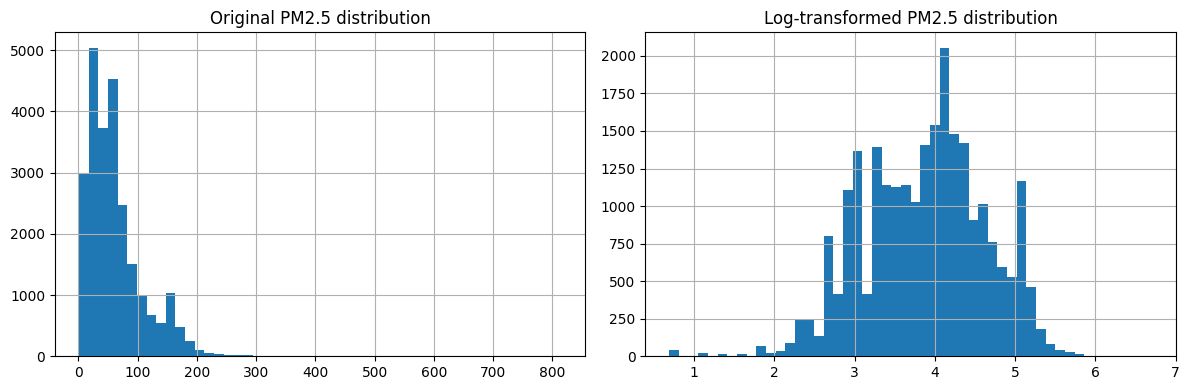

In [2]:
# Log-transform the target because PM2.5 is strongly right-skewed.
print(f"Target skewness: {y_tr.skew():.2f}")

y_tr_log = np.log1p(y_tr.reset_index(drop=True))
y_val_log = np.log1p(y_val.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr.hist(bins=50, ax=axes[0])
axes[0].set_title("Original PM2.5 distribution")
y_tr_log.hist(bins=50, ax=axes[1])
axes[1].set_title("Log-transformed PM2.5 distribution")
plt.tight_layout()
plt.show()


## Default XGBoost - All Features


Top 25 XGBoost features:
L3_AER_AI_sensor_altitude                              0.095700
L3_HCHO_tropospheric_HCHO_column_number_density        0.091834
L3_CO_CO_column_number_density                         0.066542
wind_speed_10m_above_ground                            0.065614
L3_NO2_NO2_column_number_density                       0.038340
L3_NO2_NO2_slant_column_number_density                 0.032353
L3_NO2_tropopause_pressure                             0.022301
temperature_2m_above_ground                            0.021653
L3_CLOUD_cloud_top_pressure                            0.018837
L3_NO2_sensor_altitude                                 0.018549
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.017702
specific_humidity_2m_above_ground                      0.016358
L3_AER_AI_solar_zenith_angle                           0.015791
L3_HCHO_HCHO_slant_column_number_density               0.015643
day_number                                             0.014612
L3_CLOUD_surfac

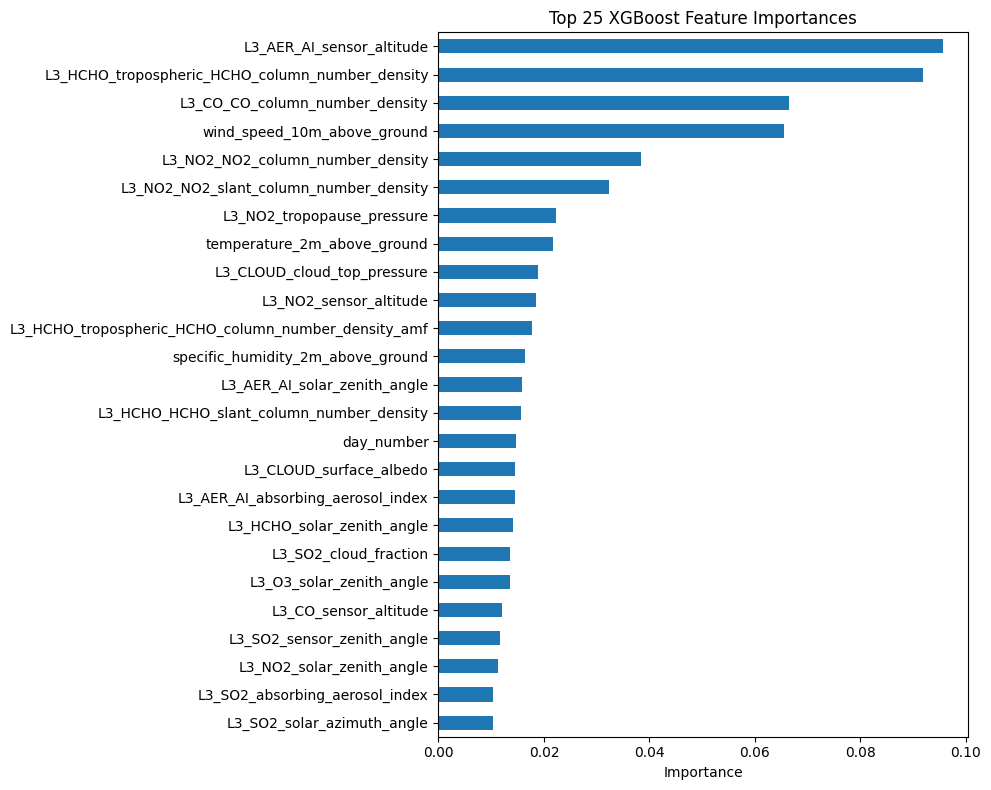

In [3]:
# Fit a default XGBoost model and use it to rank features.
xgb_default_all = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
xgb_default_all.fit(X_tr, y_tr_log)

xgb_importance = pd.Series(xgb_default_all.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
top_25_xgb_features = xgb_importance.head(25).index.tolist()

y_val_pred_xgb_default_all = np.expm1(xgb_default_all.predict(X_val))
rmse_xgb_default_all = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb_default_all))

model_scores["XGBoost default - all features"] = rmse_xgb_default_all
model_predictions["XGBoost default - all features"] = y_val_pred_xgb_default_all

print("Top 25 XGBoost features:")
print(xgb_importance.head(25))
print(f"\nDefault XGBoost RMSE (all features): {rmse_xgb_default_all:.2f} µg/m³")

xgb_importance.head(25).sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Top 25 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Save XGBoost Best Features


In [4]:
# Save XGBoost features into the shared best_features file without overwriting other model columns.
best_features_path = "data/best_features.csv"
try:
    best_features = pd.read_csv(best_features_path)
except FileNotFoundError:
    best_features = pd.DataFrame()

xgb_best_features = pd.DataFrame({
    "xgboost": xgb_importance.head(25).index,
    "xgb_feature_importance": xgb_importance.head(25).values,
})

for col in xgb_best_features.columns:
    best_features[col] = xgb_best_features[col]

best_features.to_csv(best_features_path, index=False)
print(f"Saved XGBoost top 25 features to {best_features_path}")


Saved XGBoost top 25 features to data/best_features.csv


## Default XGBoost - Top 25 Features


In [5]:
X_tr_25 = X_tr[top_25_xgb_features]
X_val_25 = X_val[top_25_xgb_features]

xgb_default_top25 = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
xgb_default_top25.fit(X_tr_25, y_tr_log)

y_val_pred_xgb_default_top25 = np.expm1(xgb_default_top25.predict(X_val_25))
rmse_xgb_default_top25 = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb_default_top25))

model_scores["XGBoost default - top 25 features"] = rmse_xgb_default_top25
model_predictions["XGBoost default - top 25 features"] = y_val_pred_xgb_default_top25

print(f"Default XGBoost RMSE (top 25 features): {rmse_xgb_default_top25:.2f} µg/m³")


Default XGBoost RMSE (top 25 features): 32.10 µg/m³


## Optional Hyperparameter Search - All Features


In [6]:
# Keep this False unless you explicitly want to rerun the expensive all-feature search.
RUN_XGB_ALL_FEATURES_SEARCH = False

xgb_param_grid = {
    "n_estimators": [300, 400, 500],
    "max_depth": [8, 9, 10, 12],
    "learning_rate": [0.03, 0.04, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.4, 0.6, 0.8, 1.0],
    "min_child_weight": [1, 2, 3],
}

def original_scale_rmse(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true, y_pred))

original_scale_rmse_scorer = make_scorer(original_scale_rmse, greater_is_better=False)

if RUN_XGB_ALL_FEATURES_SEARCH:
    search_xgb_all = RandomizedSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1),
        xgb_param_grid,
        n_iter=30,
        cv=5,
        scoring=original_scale_rmse_scorer,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    search_xgb_all.fit(X_tr, y_tr_log)

    best_xgb_all = search_xgb_all.best_estimator_
    y_val_pred_xgb_tuned_all = np.expm1(best_xgb_all.predict(X_val))
    rmse_xgb_tuned_all = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb_tuned_all))

    model_scores["XGBoost tuned - all features"] = rmse_xgb_tuned_all
    model_predictions["XGBoost tuned - all features"] = y_val_pred_xgb_tuned_all

    print("Best all-feature XGBoost params:", search_xgb_all.best_params_)
    print(f"Best CV RMSE: {-search_xgb_all.best_score_:.2f} µg/m³")
    print(f"Tuned XGBoost RMSE (all features): {rmse_xgb_tuned_all:.2f} µg/m³")
else:
    print("Skipping all-feature XGBoost hyperparameter search.")


Skipping all-feature XGBoost hyperparameter search.


## Tuned XGBoost - Top 25 Features


In [7]:
# Use a known good XGBoost parameter set by default; optionally replace it with a fresh top-25 search.
RUN_XGB_TOP25_SEARCH = False

best_xgb_params = {
    "subsample": 0.8,
    "n_estimators": 400,
    "min_child_weight": 2,
    "max_depth": 10,
    "learning_rate": 0.04,
    "colsample_bytree": 0.4,
}

if RUN_XGB_TOP25_SEARCH:
    search_xgb_top25 = RandomizedSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1),
        xgb_param_grid,
        n_iter=30,
        cv=5,
        scoring=original_scale_rmse_scorer,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    search_xgb_top25.fit(X_tr_25, y_tr_log)
    best_xgb_params = search_xgb_top25.best_params_
    print("Best top-25 XGBoost params:", best_xgb_params)
    print(f"Best CV RMSE: {-search_xgb_top25.best_score_:.2f} µg/m³")

best_xgb_top25 = XGBRegressor(
    **best_xgb_params,
    random_state=42,
    n_jobs=-1,
)
best_xgb_top25.fit(X_tr_25, y_tr_log)

y_val_pred_xgb_tuned_top25 = np.expm1(best_xgb_top25.predict(X_val_25))
rmse_xgb_tuned_top25 = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb_tuned_top25))

model_scores["XGBoost tuned - top 25 features"] = rmse_xgb_tuned_top25
model_predictions["XGBoost tuned - top 25 features"] = y_val_pred_xgb_tuned_top25

print("Best XGBoost hyperparameters:")
for param, value in best_xgb_params.items():
    print(f"{param}: {value}")

print(f"\nTuned XGBoost RMSE (top 25 features): {rmse_xgb_tuned_top25:.2f} µg/m³")
print(f"Default XGBoost RMSE (all features): {rmse_xgb_default_all:.2f} µg/m³")
print(f"Improvement vs default all features: {rmse_xgb_default_all - rmse_xgb_tuned_top25:.2f} µg/m³")


Best XGBoost hyperparameters:
subsample: 0.8
n_estimators: 400
min_child_weight: 2
max_depth: 10
learning_rate: 0.04
colsample_bytree: 0.4

Tuned XGBoost RMSE (top 25 features): 30.79 µg/m³
Default XGBoost RMSE (all features): 31.93 µg/m³
Improvement vs default all features: 1.14 µg/m³


## XGBoost Results Summary


                            Model      RMSE
  XGBoost tuned - top 25 features 30.787995
   XGBoost default - all features 31.925778
XGBoost default - top 25 features 32.096264


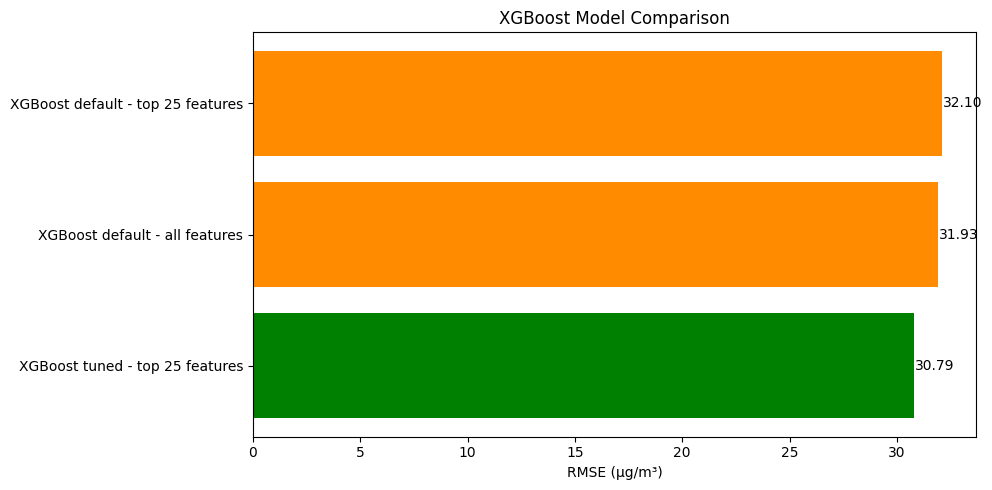

,Model,RMSE
0,XGBoost tuned - top 25 features,30.787995
1,XGBoost default - all features,31.925778
2,XGBoost default - top 25 features,32.096264


In [8]:
xgb_results = (
    pd.DataFrame({"Model": list(model_scores.keys()), "RMSE": list(model_scores.values())})
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print(xgb_results.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ["green" if rmse == xgb_results["RMSE"].min() else "darkorange" for rmse in xgb_results["RMSE"]]
plt.barh(xgb_results["Model"], xgb_results["RMSE"], color=colors)
plt.xlabel("RMSE (µg/m³)")
plt.title("XGBoost Model Comparison")
for i, value in enumerate(xgb_results["RMSE"]):
    plt.text(value + 0.05, i, f"{value:.2f}", va="center")
plt.tight_layout()
plt.show()

xgb_results


## XGBoost Diagnostics


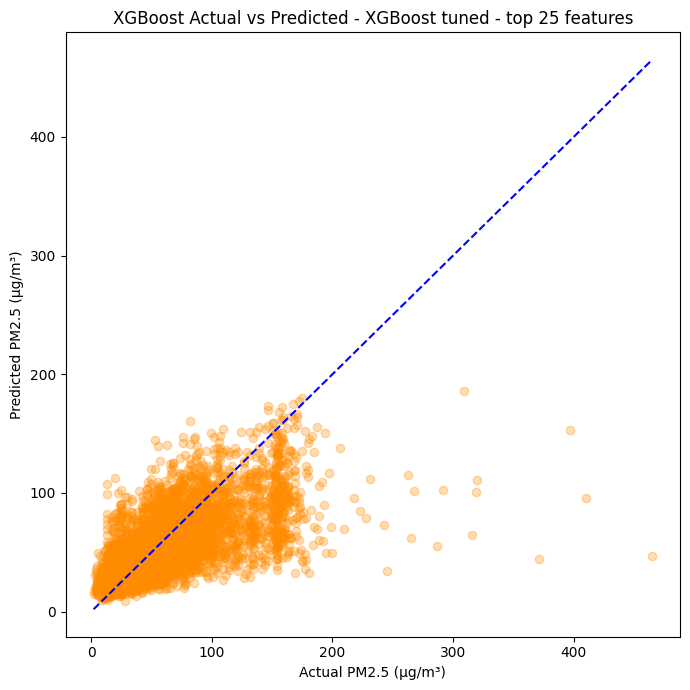

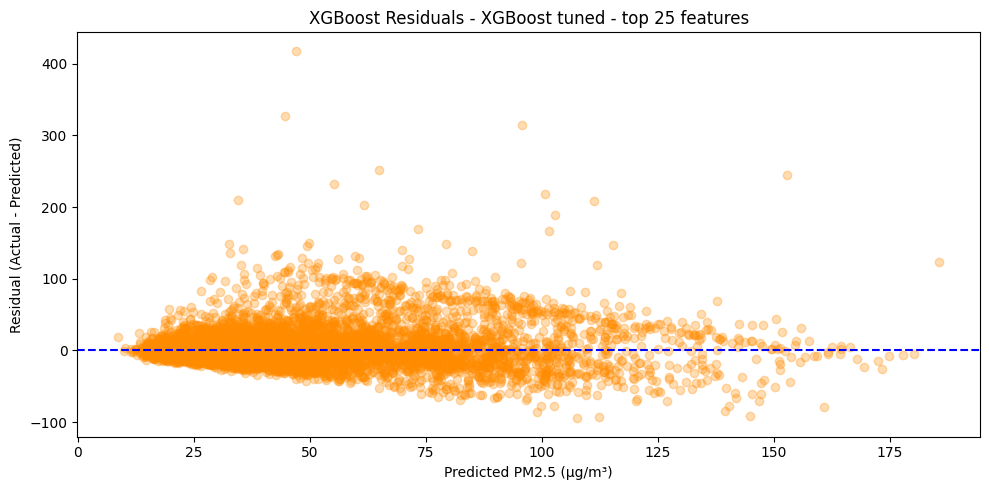

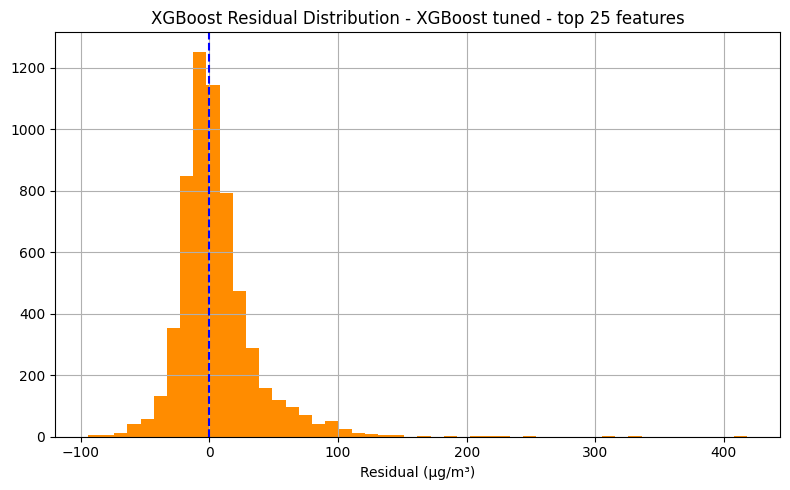

In [9]:
# Diagnose the strongest available XGBoost model.
best_model_name = xgb_results.loc[0, "Model"]
best_prediction = model_predictions[best_model_name]
residuals = y_val - best_prediction

plt.figure(figsize=(7, 7))
plt.scatter(y_val, best_prediction, alpha=0.3, color="darkorange")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "b--")
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title(f"XGBoost Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(best_prediction, residuals, alpha=0.3, color="darkorange")
plt.axhline(0, color="blue", linestyle="--")
plt.xlabel("Predicted PM2.5 (µg/m³)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"XGBoost Residuals - {best_model_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
residuals.hist(bins=50, color="darkorange")
plt.axvline(0, color="blue", linestyle="--")
plt.xlabel("Residual (µg/m³)")
plt.title(f"XGBoost Residual Distribution - {best_model_name}")
plt.tight_layout()
plt.show()
